#Extração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

df_bruto = pd.read_json(url)
df = pd.json_normalize(df_bruto.to_dict(orient="records"), sep="_")

#Transformação

In [2]:
df.shape

(7267, 21)

In [3]:
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [5]:
df.isnull().sum().sort_values(ascending=False)

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [6]:
(df == "").sum().sort_values(ascending=False)

,0
Churn,224
customerID,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [7]:
(df == " ").sum().sort_values(ascending=False)

,0
account_Charges_Total,11
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customerID,0
customer_Partner,0
customer_Dependents,0
phone_PhoneService,0
customer_tenure,0
internet_InternetService,0


In [8]:
df["customerID"].duplicated().sum()

np.int64(0)

In [9]:
df.nunique().sort_values()

,0
customer_SeniorCitizen,2
customer_gender,2
customer_Dependents,2
customer_Partner,2
phone_PhoneService,2
account_PaperlessBilling,2
internet_InternetService,3
Churn,3
internet_DeviceProtection,3
internet_TechSupport,3


In [10]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [11]:
df[(df["customer_tenure"] == 0) & (df["account_Charges_Total"] != " ")]

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total


In [12]:
df[(df["internet_InternetService"] == "No") & (df["internet_OnlineSecurity"] == "Yes")]

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total


In [13]:
df = df[df["Churn"].str.strip() != ""]
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [14]:
df.loc[df["account_Charges_Total"].str.strip() == "", "customer_tenure"]

,customer_tenure
975,0
1775,0
1955,0
2075,0
2232,0
2308,0
2930,0
3134,0
3203,0
4169,0


In [15]:
df["account_Charges_Total"] = df["account_Charges_Total"].replace(" ", 0)
df["account_Charges_Total"] = df["account_Charges_Total"].astype(float)

In [16]:
colunas_binarias = []

for col in df.columns:
    if df[col].dropna().isin(["Yes", "No"]).all():
        colunas_binarias.append(col)

colunas_binarias

['Churn',
 'customer_Partner',
 'customer_Dependents',
 'phone_PhoneService',
 'account_PaperlessBilling']

In [17]:
for col in colunas_binarias:
    df[col] = df[col].map({"Yes": 1, "No": 0})

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   int64  
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   int64  
 5   customer_Dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   int64  
 8   phone_MultipleLines        7043 non-null   object 
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   object 
 11  internet_OnlineBackup      7043 non-null   object 
 12  internet_DeviceProtection  7043 non-null   object 
 13  internet_TechSupport       7043 non-null   object 
 1

In [19]:
df = df.rename(columns={
    "customerID": "id_cliente",
    "Churn": "evasao",
    "customer_gender": "genero",
    "customer_SeniorCitizen": "idoso",
    "customer_Partner": "parceiro",
    "customer_Dependents": "dependentes",
    "customer_tenure": "tempo_contrato",
    "phone_PhoneService": "servico_telefone",
    "phone_MultipleLines": "multiplas_linhas",
    "internet_InternetService": "servico_internet",
    "internet_OnlineSecurity": "seguranca_online",
    "internet_OnlineBackup": "backup_online",
    "internet_DeviceProtection": "protecao_dispositivo",
    "internet_TechSupport": "suporte_tecnico",
    "internet_StreamingTV": "streaming_tv",
    "internet_StreamingMovies": "streaming_filmes",
    "account_Contract": "tipo_contrato",
    "account_PaperlessBilling": "fatura_digital",
    "account_PaymentMethod": "metodo_pagamento",
    "account_Charges_Monthly": "cobranca_mensal",
    "account_Charges_Total": "cobranca_total"
})

df.head()

,id_cliente,evasao,genero,idoso,parceiro,dependentes,tempo_contrato,servico_telefone,multiplas_linhas,servico_internet,...,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40


In [20]:
df["metodo_pagamento"].value_counts()

,count
metodo_pagamento,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [21]:
df["genero"] = df["genero"].map({
    "Male": "Masculino",
    "Female": "Feminino"
})

In [22]:
df["multiplas_linhas"] = df["multiplas_linhas"].map({
    "Yes": "Sim",
    "No": "Não",
    "No phone service": "Sem serviço de telefone"
})

In [23]:
df["servico_internet"] = df["servico_internet"].map({
    "DSL": "DSL",
    "Fiber optic": "Fibra óptica",
    "No": "Sem internet"
})

In [24]:
colunas_de_internet = [
    "seguranca_online",
    "backup_online",
    "protecao_dispositivo",
    "suporte_tecnico",
    "streaming_tv",
    "streaming_filmes"
]

for col in colunas_de_internet:
    df[col] = df[col].map({
        "Yes": "Sim",
        "No": "Não",
        "No internet service": "Sem serviço de internet"
    })

In [25]:
df["tipo_contrato"] = df["tipo_contrato"].map({
    "Month-to-month": "Mensal",
    "One year": "Anual",
    "Two year": "Dois anos"
})

In [26]:
df["metodo_pagamento"] = df["metodo_pagamento"].map({
    "Electronic check": "Cheque eletrônico",
    "Mailed check": "Cheque por correio",
    "Bank transfer (automatic)": "Transferência bancária automática",
    "Credit card (automatic)": "Cobrança recorrente no cartão"
})

In [27]:
df["custo_diario"] = (df["cobranca_mensal"] / 30).round(2)

#Carga e Análise

In [28]:
print("Estatísticas Básicas das Variáveis Numéricas:")
df.describe()

Estatísticas Básicas das Variáveis Numéricas:


,evasao,idoso,parceiro,dependentes,tempo_contrato,servico_telefone,fatura_digital,cobranca_mensal,cobranca_total,custo_diario
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [29]:
colunas_categoricas = df.select_dtypes(exclude=[np.number]).columns

print("Distribuição das Variáveis Categóricas:")
for col in colunas_categoricas:
  if col == "id_cliente":
    continue
  print(f"\nColuna: {col}")
  print("- Frequência Absoluta:")
  print(df[col].value_counts())
  print("- Frequência Relativa:")
  print((df[col].value_counts(normalize=True) * 100).round(2))

Distribuição das Variáveis Categóricas:

Coluna: genero
- Frequência Absoluta:
genero
Masculino    3555
Feminino     3488
Name: count, dtype: int64
- Frequência Relativa:
genero
Masculino    50.48
Feminino     49.52
Name: proportion, dtype: float64

Coluna: multiplas_linhas
- Frequência Absoluta:
multiplas_linhas
Não                        3390
Sim                        2971
Sem serviço de telefone     682
Name: count, dtype: int64
- Frequência Relativa:
multiplas_linhas
Não                        48.13
Sim                        42.18
Sem serviço de telefone     9.68
Name: proportion, dtype: float64

Coluna: servico_internet
- Frequência Absoluta:
servico_internet
Fibra óptica    3096
DSL             2421
Sem internet    1526
Name: count, dtype: int64
- Frequência Relativa:
servico_internet
Fibra óptica    43.96
DSL             34.37
Sem internet    21.67
Name: proportion, dtype: float64

Coluna: seguranca_online
- Frequência Absoluta:
seguranca_online
Não                        3498

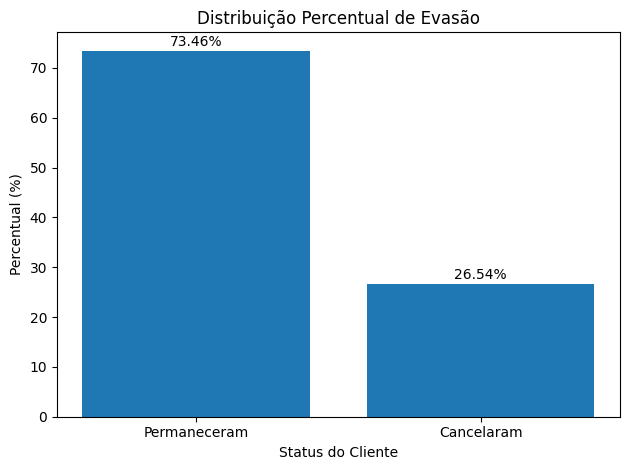

In [30]:
contagem_evasao = df["evasao"].value_counts().sort_index()
porcentagem_evasao = df["evasao"].value_counts(normalize=True).sort_index() * 100

plt.figure()
plt.bar(["Permaneceram", "Cancelaram"], porcentagem_evasao)

plt.title("Distribuição Percentual de Evasão")
plt.ylabel("Percentual (%)")
plt.xlabel("Status do Cliente")

for i, v in enumerate(porcentagem_evasao):
  plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.tight_layout()
plt.show()


Análise: evasao x genero

- Tabela de Contagem:
evasao        0    1
genero              
Feminino   2549  939
Masculino  2625  930

- Taxa de Evasão (%):
evasao         0      1
genero                 
Feminino   73.08  26.92
Masculino  73.84  26.16


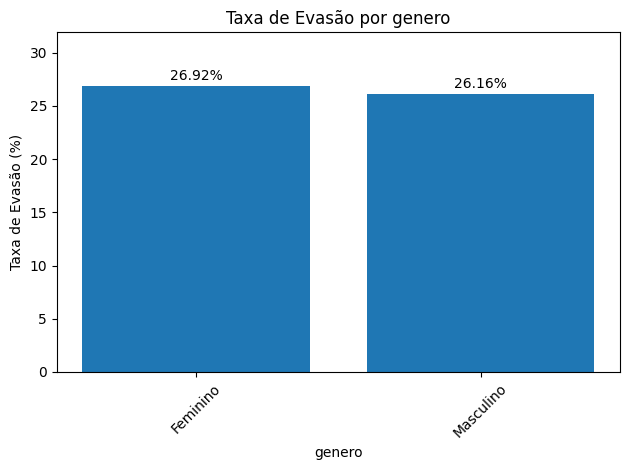


Análise: evasao x servico_internet

- Tabela de Contagem:
evasao               0     1
servico_internet            
DSL               1962   459
Fibra óptica      1799  1297
Sem internet      1413   113

- Taxa de Evasão (%):
evasao                0      1
servico_internet              
DSL               81.04  18.96
Fibra óptica      58.11  41.89
Sem internet      92.60   7.40


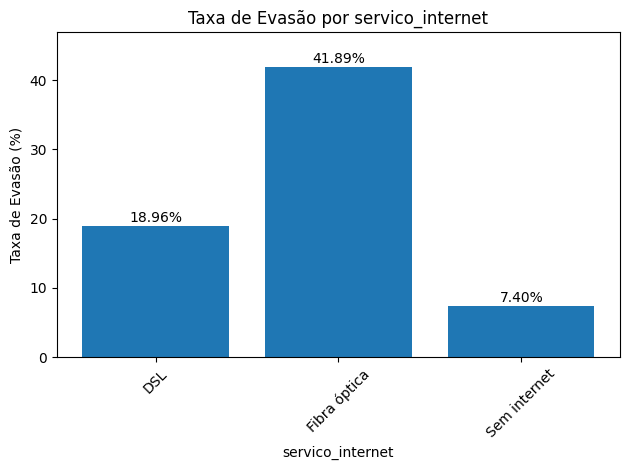


Análise: evasao x tipo_contrato

- Tabela de Contagem:
evasao            0     1
tipo_contrato            
Anual          1307   166
Dois anos      1647    48
Mensal         2220  1655

- Taxa de Evasão (%):
evasao             0      1
tipo_contrato              
Anual          88.73  11.27
Dois anos      97.17   2.83
Mensal         57.29  42.71


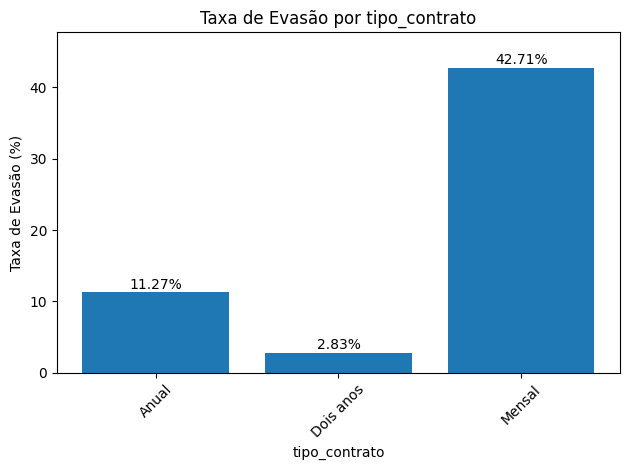


Análise: evasao x metodo_pagamento

- Tabela de Contagem:
evasao                                0     1
metodo_pagamento                             
Cheque eletrônico                  1294  1071
Cheque por correio                 1304   308
Cobrança recorrente no cartão      1290   232
Transferência bancária automática  1286   258

- Taxa de Evasão (%):
evasao                                 0      1
metodo_pagamento                               
Cheque eletrônico                  54.71  45.29
Cheque por correio                 80.89  19.11
Cobrança recorrente no cartão      84.76  15.24
Transferência bancária automática  83.29  16.71


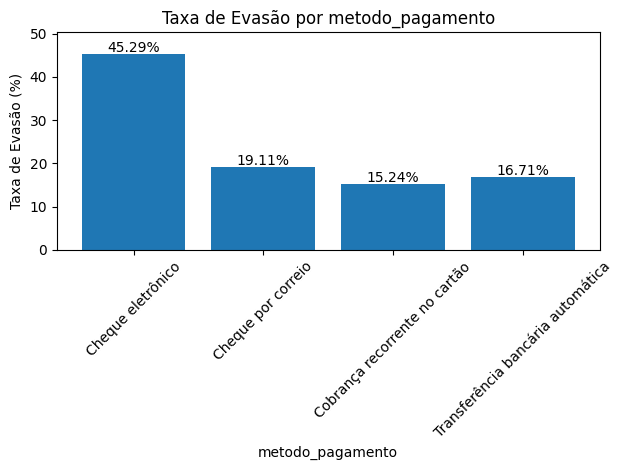

In [31]:
variaveis_categoricas = [
    "genero",
    "servico_internet",
    "tipo_contrato",
    "metodo_pagamento"
]

for var in variaveis_categoricas:
  print(f"\nAnálise: evasao x {var}")

  tabela_contagem = pd.crosstab(df[var], df["evasao"])
  print("\n- Tabela de Contagem:")
  print(tabela_contagem)


  tabela_percentual = pd.crosstab(df[var], df["evasao"], normalize='index') * 100
  print("\n- Taxa de Evasão (%):")
  print(tabela_percentual.round(2))

  taxa_evasao = tabela_percentual[1]

  plt.figure()
  plt.bar(taxa_evasao.index, taxa_evasao.values)

  plt.title(f"Taxa de Evasão por {var}")
  plt.ylabel("Taxa de Evasão (%)")
  plt.xlabel(var)
  plt.xticks(rotation=45)
  plt.ylim(0, taxa_evasao.max() + 5)

  for i, v in enumerate(taxa_evasao.values):
        plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

  plt.tight_layout()
  plt.show()

Análise: evasao x idoso

Tabela de Contagem:
evasao     0     1
idoso             
0       4508  1393
1        666   476

Taxa de Evasão (%):
evasao      0      1
idoso               
0       76.39  23.61
1       58.32  41.68


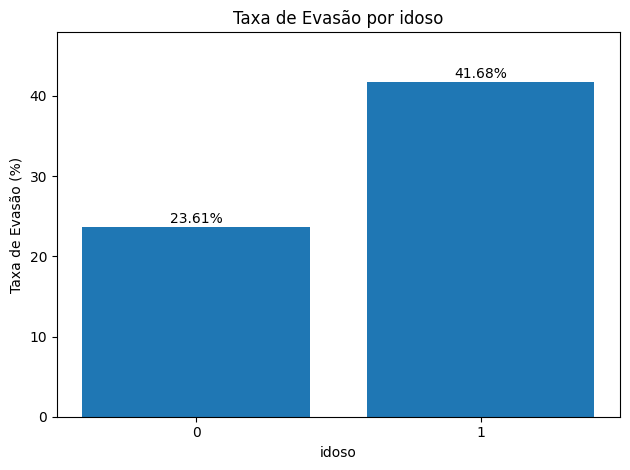

Análise: evasao x parceiro

Tabela de Contagem:
evasao       0     1
parceiro            
0         2441  1200
1         2733   669

Taxa de Evasão (%):
evasao        0      1
parceiro              
0         67.04  32.96
1         80.34  19.66


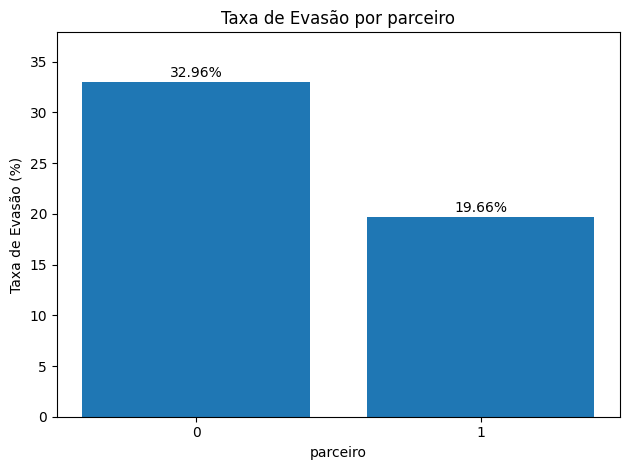

Análise: evasao x dependentes

Tabela de Contagem:
evasao          0     1
dependentes            
0            3390  1543
1            1784   326

Taxa de Evasão (%):
evasao           0      1
dependentes              
0            68.72  31.28
1            84.55  15.45


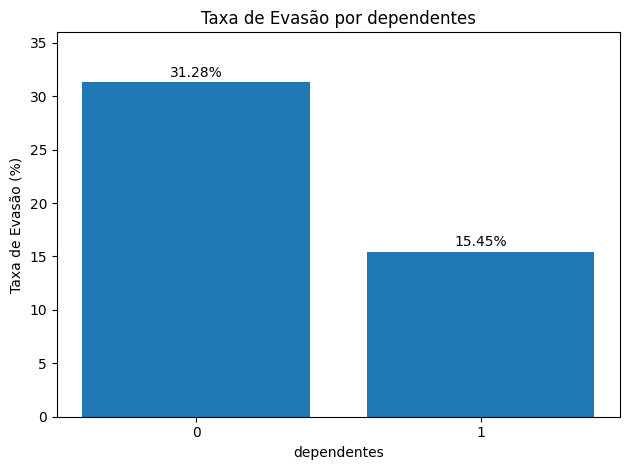

Análise: evasao x servico_telefone

Tabela de Contagem:
evasao               0     1
servico_telefone            
0                  512   170
1                 4662  1699

Taxa de Evasão (%):
evasao                0      1
servico_telefone              
0                 75.07  24.93
1                 73.29  26.71


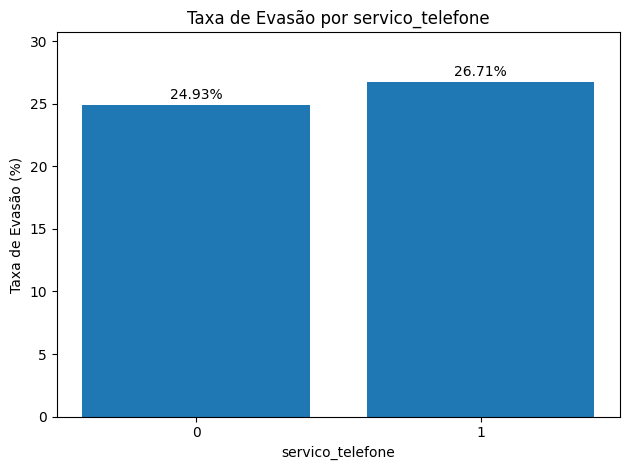

Análise: evasao x fatura_digital

Tabela de Contagem:
evasao             0     1
fatura_digital            
0               2403   469
1               2771  1400

Taxa de Evasão (%):
evasao              0      1
fatura_digital              
0               83.67  16.33
1               66.43  33.57


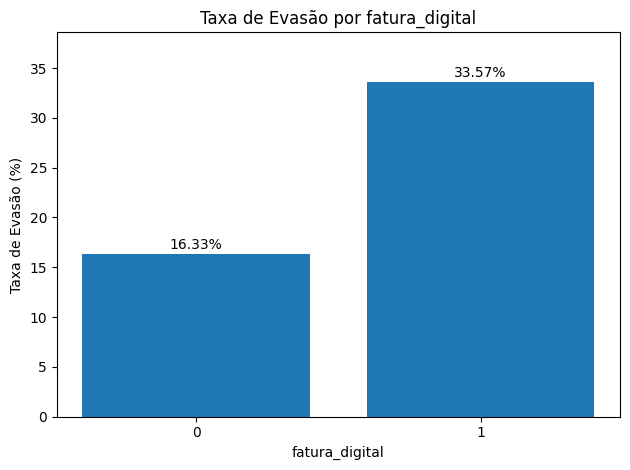

In [32]:
variaveis_binarias = [
    "idoso",
    "parceiro",
    "dependentes",
    "servico_telefone",
    "fatura_digital",
]

for var in variaveis_binarias:
  print(f"Análise: evasao x {var}")

  tabela_contagem = pd.crosstab(df[var], df["evasao"])
  print("\nTabela de Contagem:")
  print(tabela_contagem)

  tabela_percentual = pd.crosstab(df[var], df["evasao"], normalize='index') * 100
  print("\nTaxa de Evasão (%):")
  print(tabela_percentual.round(2))

  taxa_evasao = tabela_percentual[1]

  plt.figure()
  plt.bar(taxa_evasao.index.astype(str), taxa_evasao.values)

  plt.title(f"Taxa de Evasão por {var}")
  plt.ylabel("Taxa de Evasão (%)")
  plt.xlabel(var)

  plt.ylim(0, taxa_evasao.max() * 1.15)

  for i, v in enumerate(taxa_evasao.values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

  plt.tight_layout()
  plt.show()


Estatísticas de tempo_contrato por Evasão:
         count       mean        std  min   25%   50%   75%   max
evasao                                                           
0       5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
1       1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


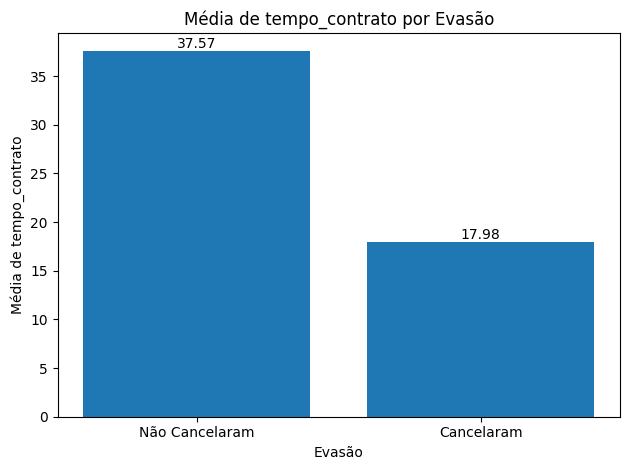

<Figure size 640x480 with 0 Axes>

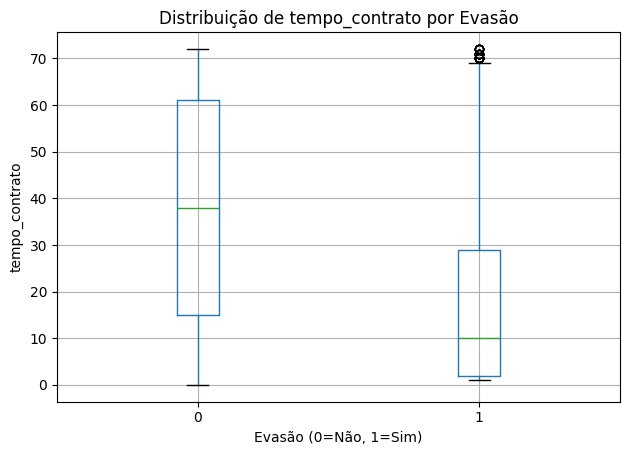


Estatísticas de cobranca_mensal por Evasão:
         count       mean        std    min    25%     50%   75%     max
evasao                                                                  
0       5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
1       1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


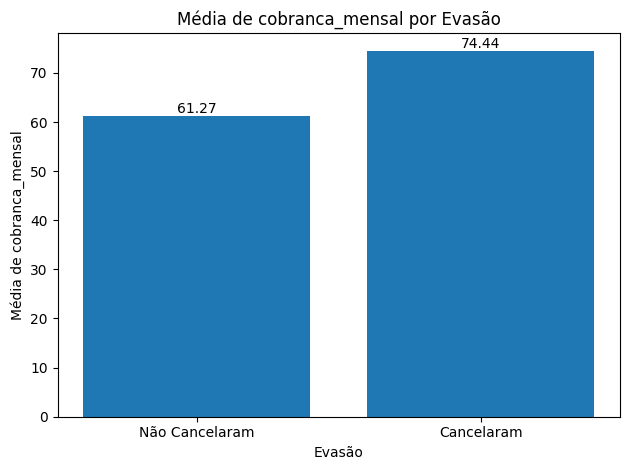

<Figure size 640x480 with 0 Axes>

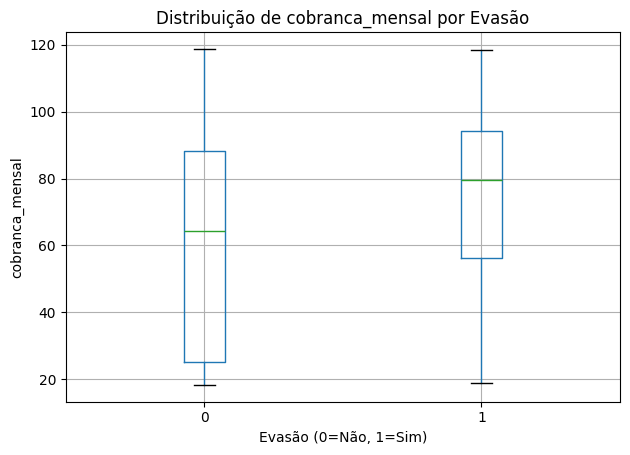


Estatísticas de cobranca_total por Evasão:
         count         mean          std    min    25%       50%      75%  \
evasao                                                                      
0       5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85   
1       1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30   

            max  
evasao           
0       8672.45  
1       8684.80  


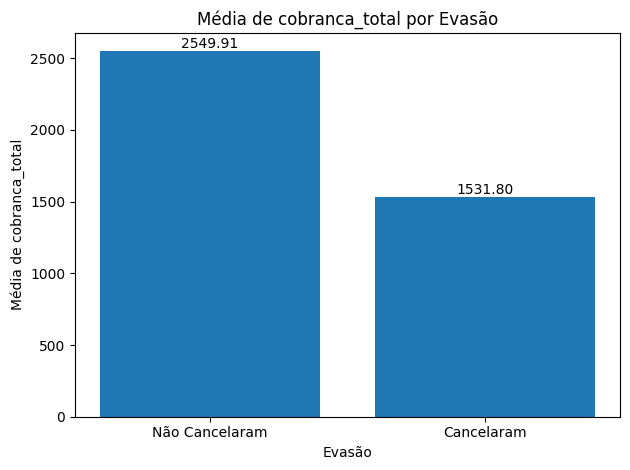

<Figure size 640x480 with 0 Axes>

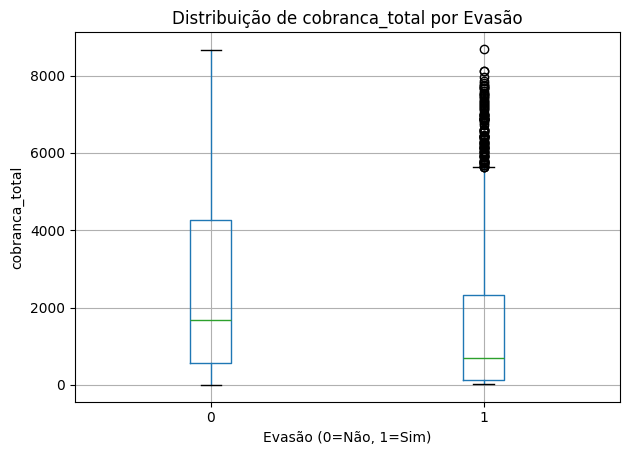

In [33]:
variaveis_continuas = [
    "tempo_contrato",
    "cobranca_mensal",
    "cobranca_total"
]

for var in variaveis_continuas:
  estatisticas = df.groupby("evasao")[var].describe()
  print(f"\nEstatísticas de {var} por Evasão:")
  print(estatisticas)

  medias = df.groupby("evasao")[var].mean()

  plt.figure()
  plt.bar(["Não Cancelaram", "Cancelaram"], medias.values)

  plt.title(f"Média de {var} por Evasão")
  plt.ylabel(f"Média de {var}")
  plt.xlabel("Evasão")

  for i, v in enumerate(medias.values):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

  plt.tight_layout()
  plt.show()

  plt.figure()
  df.boxplot(column=var, by="evasao")
  plt.title(f"Distribuição de {var} por Evasão")
  plt.suptitle("")
  plt.xlabel("Evasão (0=Não, 1=Sim)")
  plt.ylabel(var)
  plt.tight_layout()
  plt.show()

#Relatório Final

OBJETIVO: foi realizada uma análise dos dados da empresa Telecom X, pois os gestores suspeitam que a empresa esteja perdendo muitos clientes. O objetivo dessa análise foi identificar se esse problema realmente existe, avaliando o churn (taxa de evasão) de clientes e, caso as suspeitas se concretizem, descobrir as possíveis causas para os clientes estarem abandonando o serviço.

##Limpeza e Tratamento de Dados

Antes de poder iniciar a análise, foi necessário limpar e tratar os dados da base de dados principal. O primeiro passo, logo ao importar a base de dados em formato JSON, foi usar uma função para normalizar as colunas da base, pois estava com muitas estruturas aninhadas. Dessa forma, a base pôde ser transformada em um Data Frame da biblioteca Pandas da linguagem Python. Após uma breve avaliação das condições desses dados, não foi encontrado nenhum valor nulo, nem valor duplicado que pudesse comprometer a análise, mas foram encontrados outros problemas.

A base possuía campos em branco em alguns registros da variável taxa de evasão, a informação mais importante dessa análise. Por isso, foi tomada a decisão de remover da análise todos os registros com essa informação faltante. Outro problema era que a variável que mostrava o valor total já gasto pelo cliente com a empresa não estava armazenada como número, o que impedia qualquer tipo de cálculo envolvendo essa variável. Também foram encontrados campos vazios nessa mesma coluna, mas após uma inspeção, foi revelado que esses campos vazios estavam associados à novos clientes que ainda não haviam feito nenhum pagamento. Então, esses campos foram substituídos pelo número zero e a variável foi propriamente convertida a um valor numérico. Por fim, foi encontrada uma inconsistência na forma como variáveis que representavam apenas “Sim” ou “Não” eram exibidas. Todas as variáveis que correspondiam à esse critério foram padronizadas para: “Sim” se tornou “1” e “Não” se tornou “0”, o que permite uma maior liberdade durante a avaliação desses dados.

Como a empresa Telecom X é uma multinacional, todos seus dados de origem estavam na língua inglesa. Pensando na acessibilidade, para facilitar o trabalho dos analistas e melhorar a compreensão daqueles que virão a ler essa análise, toda a base de dados foi traduzida do inglês para o português do Brasil. Os termos foram traduzidos de forma literal, mesmo que não sejam culturalmente comuns em território brasileiro. Como foi o exemplo de um dos métodos de pagamento, “Electronic check”, que foi traduzido como “Cheque eletrônico”, por não termos a mesma forma de pagamento por aqui. Após esses procedimentos, a base estava pronta para análise.

##Análise Exploratória de Dados

A análise foi iniciada obtendo estatísticas básicas relacionadas às variáveis numéricas e avaliando como as variáveis categóricas estão distribuídas, mas logo após isso, o objetivo principal dessa análise já começou a ser estudado. Conforme o gráfico abaixo mostra, a taxa geral de evasão identificada foi de 26,54%, indicando que aproximadamente 1 a cada 4 clientes cancela o serviço. Trata-se de um índice elevado e com impacto direto na receita, o que justifica a preocupação dos gestores. Agora que o problema havia sido confirmado, a análise foi conduzida cruzando a variável de evasão com características demográficas, contratuais, comportamentais e financeiras dos clientes.

<img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/percentual_evasao.png" alt="Gráfico de percentual de evasão" width="50%" />

Esse processo foi iniciado cruzando a evasão com as variáveis categóricas da base de dados. Não foi encontrada nenhuma relação significante entre evasão e o gênero do cliente. Mas o mesmo não pode ser dito sobre as variáveis serviço de internet, tipo de contrato e método de pagamento. Clientes de fibra óptica têm 41,89% de evasão, mais que o dobro do DSL e quase 6x mais que quem não tem internet. Isso pode acontecer devido ao fato da fibra ser mais cara, o que indicaria uma sensibilidade dos clientes maior ao preço; por ser um serviço mais avançado, isso pode gerar expectativas mais altas, o que gera uma maior frustração caso elas não sejam correspondidas; ou a empresa pode ter uma concorrência mais agressiva especificamente nesse segmento.

<img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/evasao_genero.png" alt="Evasão X Idosos" width="50%" /><img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/evasao_servico_internet.png" alt="Evasão X Serviço de Internet" width="50%" />

Um dos principais determinantes da evasão está sendo o tipo de contrato. Contratos mensais têm uma taxa de evasão 15x maior que os contratos de dois anos, 42,71% contra 2,83%. Se a empresa estiver incentivando demais contratos mensais, isso seria uma explicação para o alto churn. O método de pagamento também está influenciando, clientes que optaram por cheque eletrônico possuem uma taxa de evasão maior, isso pode indicar que clientes que preferem esse método são mais sensíveis a preços ou que são clientes com uma menor estabilidade financeira. Até agora o padrão observado é que o perfil de maior risco são clientes de fibra óptica, com contrato mensal e pagando por cheque eletrônico.

<img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/evasao_tipo_contrato.png" alt="Evasão X Tipo de Contrato" width="50%" /><img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/evasao_metodo_pagamento.png" alt="Evasão X Método de Pagamento" width="50%" />

Ao analisar as variáveis numéricas que são binárias, um padrão interessante foi encontrado. Clientes com parceiros e clientes com dependentes, possuem um churn significativamente menor que os que não possuem. Isso pode indicar que clientes com estrutura familiar possuem uma dependência maior ao serviço, uma menor probabilidade de realizarem um cancelamento impulsivo e uma maior aversão ao risco. Também foi observado que clientes idosos cancelam mais que os outros, o que pode ser explicado por uma possível dificuldade com tecnologia ou menor tolerância a problemas técnicos.

<img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/evasao_parceiro.png" alt="Evasão X Parceiro" width="50%" /><img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/evasao_dependentes.png" alt="Evasão X Dependentes" width="50%" />

<img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/evasao_idoso.png" alt="Evasão X Idoso" width="50%" />

O problema ficou ainda mais claro ao observar as variáveis numéricas contínuas. A média do tempo de contrato dos clientes que não cancelaram é 37,6 meses, enquanto a média dos que cancelaram é 18 meses, o churn é fortemente concentrado nos primeiros meses. Isso indica que a maioria dos clientes que cancelam, fazem isso cedo. A análise também mostrou que o preço importa, os clientes que estão cancelando pagam, em média, mais caro. A mensalidade média de clientes que ainda mantém o serviço é 61,26 reais contra 74,44 reais dos que cancelaram.

<img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/evasao_tempo_contrato.png" alt="Evasão X Média do Tempo de Contrato" width="50%" /><img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/boxplot_evasao_tempo_contrato.png" alt="Boxplot de Evasão X Tempo de Contrato" width="50%" />

<img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/evasao_cobranca_mensal.png" alt="Evasão X Média da Cobrança Mensal" width="50%" /><img src="https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x/refs/heads/main/images/boxplot_evasao_cobranca_mensal.png" alt="Boxplot de Evasão X Cobrança Mensal" width="50%" />

##Conclusão e Sugestões

A empresa realmente está sofrendo de uma alta taxa de evasão. O vínculo contratual é um dos maiores determinantes de permanência, os clientes com contrato mensal são os que mais cancelam. O churn ocorre predominantemente nos primeiros meses de relacionamento, indicando possível falha no onboarding, na percepção de valor inicial ou na retenção precoce. Clientes que assinam fibra óptica são um grupo de alto risco, as possíveis causas são um ticket médio elevado, expectativa maior por qualidade e concorrência mais disputada nessa área. Preço mais alto está associado a maior risco de evasão.

Pagamento por cheque eletrônico está fortemente associado à evasão. O que pode ser justificado por um perfil de clientes mais sensível a preço, menor estabilidade financeira ou menor vínculo automatizado com a empresa. Analisando o perfil demográfico dos clientes descobriu-se que estrutura familiar está associada à maior estabilidade. Clientes sozinhos e clientes idosos apresentam maior risco de evasão.

O cliente com maior probabilidade de evasão tende a apresentar: contrato mensal, serviço de fibra óptica, cobrança mensal mais alta, pagamento por cheque eletrônico, tempo de contrato menor que 12 meses, sem parceiro ou dependentes. Esse padrão sugere que a evasão não é aleatória, mas sim concentrada em segmentos específicos.

Levando isso em conta, considerem essas sugestões que podem ajudar a minimizar o cancelamento. Para reduzir o churn dos primeiros 12 meses, pode ser elaborado um programa estruturado de onboarding e podem oferecer ofertas de upgrade ou benefícios temporários. É preciso incentivar a escolha de contratos longos, seja com descontos progressivos por fidelidade ou benefícios exclusivos para contratos anuais ou de dois anos, por exemplo. Também é preciso criar incentivos a pagamentos automáticos, como descontos para pagamentos recorrentes ou em débito automático.

É importante apurar a fundo e realizar uma revisão estratégica do serviço de fibra óptica. Incluindo avaliar percepção de qualidade, analisar a competitividade do preço, investigar reclamações técnicas e considerar ajustar a comunicação de proposta de valor. Considerem criar uma abordagem de marketing e atendimento específica para o público solteiro, sem dependentes e idosos, criando uma estratégia segmentada por perfil do cliente.

Se ações direcionadas forem implementadas com base nesses achados, a redução da evasão pode ser significativa e sustentável.

